<a href="https://colab.research.google.com/github/thegurdian/ML/blob/main/pabna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df=pd.read_csv("/content/pabna_diabetes.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No. of Pregnancy     465 non-null    int64  
 1   Age                  465 non-null    int64  
 2   BMI                  465 non-null    float64
 3   BP(Systolic)         465 non-null    int64  
 4   BP(Diastolic)        465 non-null    int64  
 5   Genetic              465 non-null    int64  
 6   Insulin              465 non-null    int64  
 7   Skin Thickness(mm)   465 non-null    float64
 8   Glucose Consumption  465 non-null    float64
 9   Outcome              465 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 36.5 KB


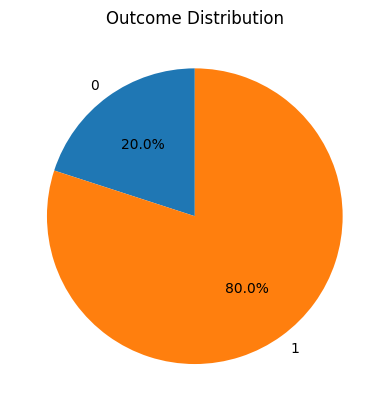

In [19]:
df_copy = df.copy()
import matplotlib.pyplot as plt

counts = df_copy["Outcome"].value_counts().sort_index()

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Outcome Distribution")
plt.show()

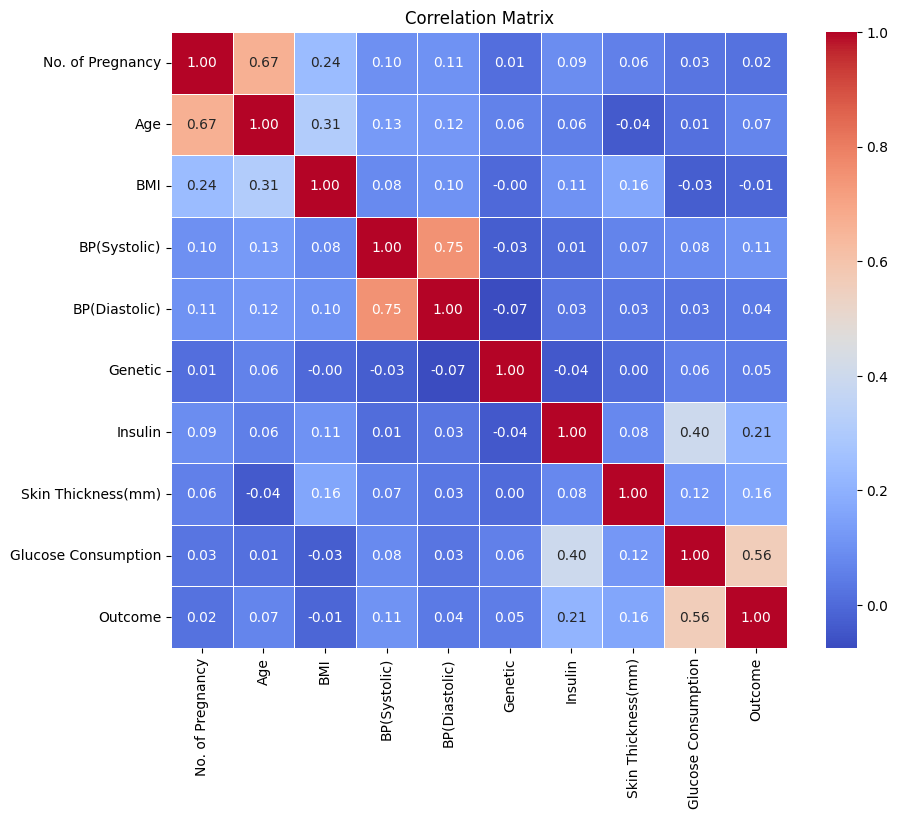

In [20]:
corr_matrix = df_copy.corr(numeric_only=True)

corr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

In [21]:
print(df_copy['Insulin'].dtype)

int64


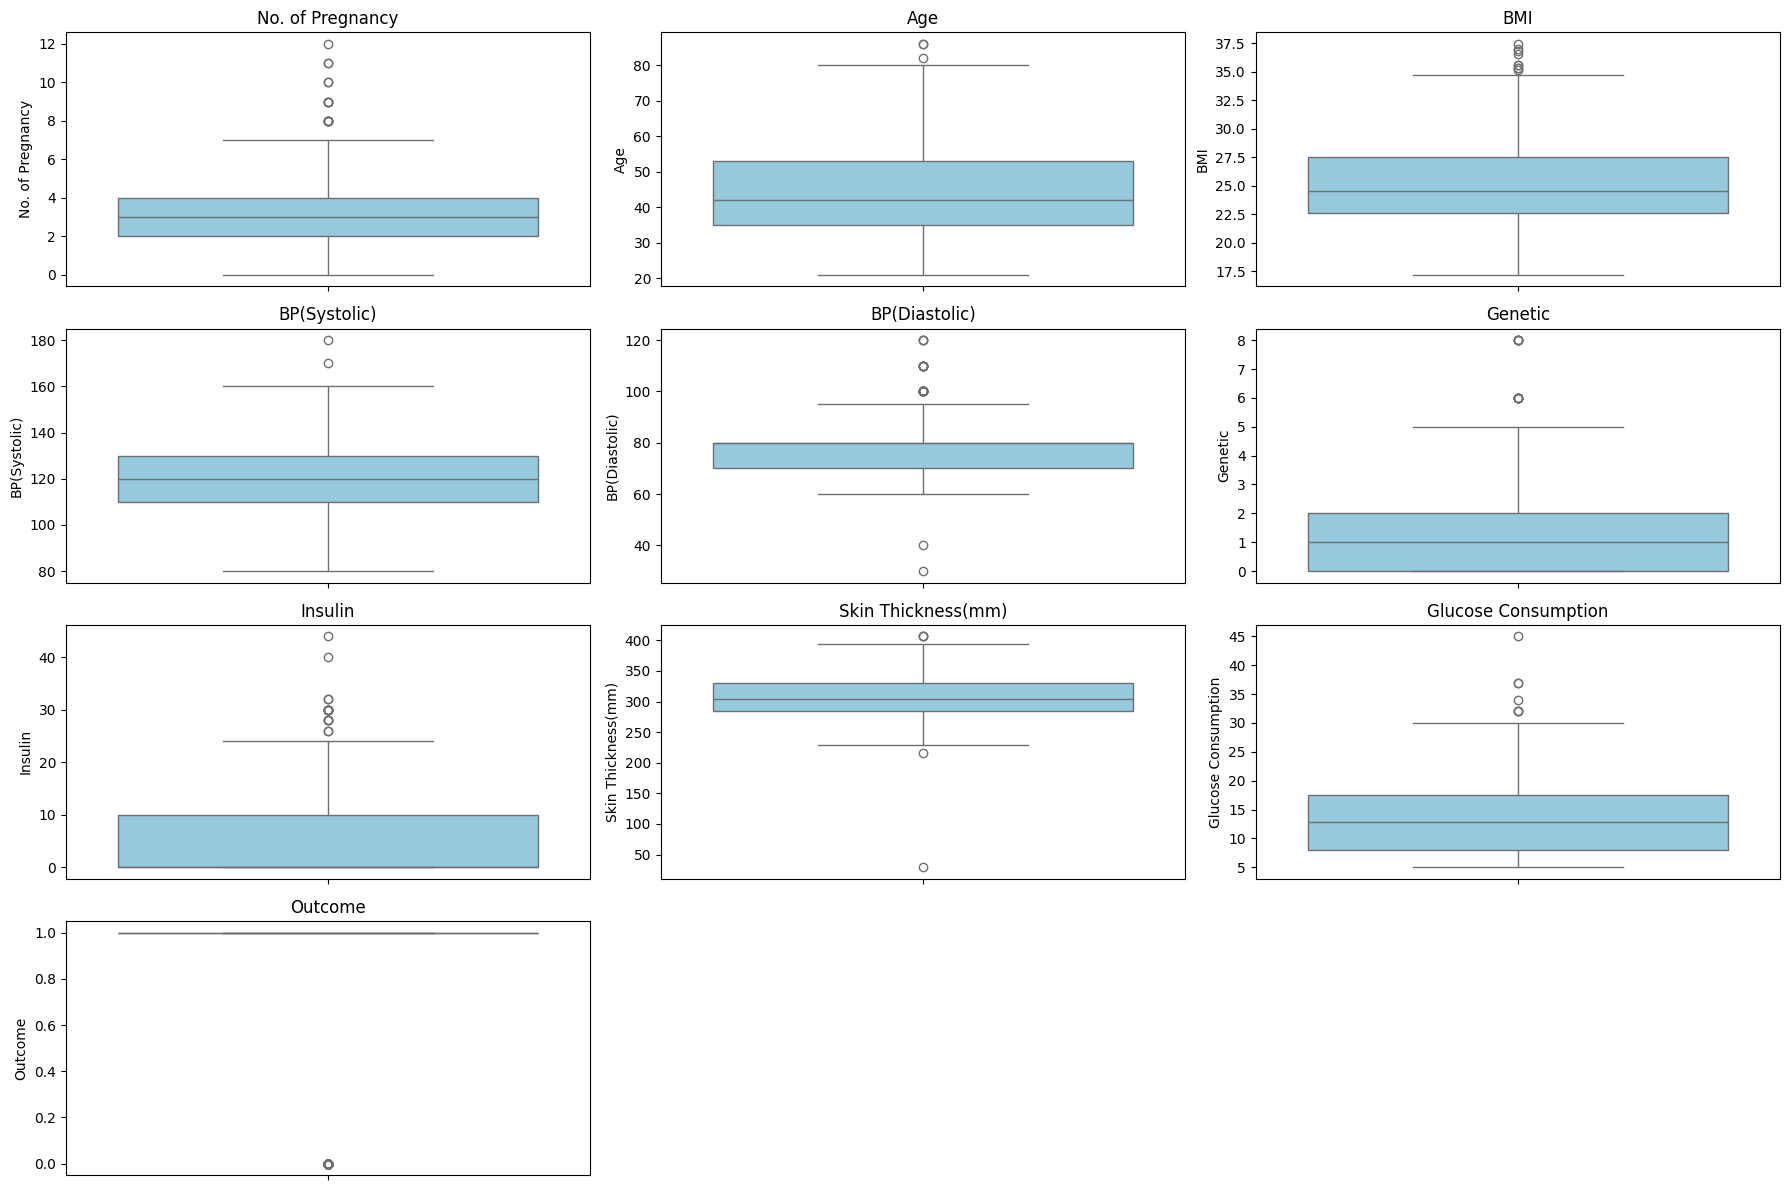

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df_copy.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(18, 12))

for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [23]:
corr_with_target = (
    corr_matrix["Outcome"]
    .sort_values(ascending=False)
)

print(corr_with_target)

Outcome                1.000000
Glucose Consumption    0.560214
Insulin                0.206835
Skin Thickness(mm)     0.164655
BP(Systolic)           0.107647
Age                    0.068610
Genetic                0.048495
BP(Diastolic)          0.039554
No. of Pregnancy       0.021577
BMI                   -0.007894
Name: Outcome, dtype: float64


In [24]:
import pandas as pd

zero_summary = pd.DataFrame({
    'Zero Count': (df_copy == 0).sum(),
    'Zero Percentage': ((df_copy == 0).mean() * 100).round(2)
})

print(zero_summary)

                     Zero Count  Zero Percentage
No. of Pregnancy             20             4.30
Age                           0             0.00
BMI                           0             0.00
BP(Systolic)                  0             0.00
BP(Diastolic)                 0             0.00
Genetic                     172            36.99
Insulin                     334            71.83
Skin Thickness(mm)            0             0.00
Glucose Consumption           0             0.00
Outcome                      93            20.00


In [25]:
import numpy as np
from sklearn.impute import SimpleImputer

# Step 1: Replace 0 with NaN
df_copy['Insulin'] = df_copy['Insulin'].replace(0, np.nan)

# Step 2: Create the imputer
imputer = SimpleImputer(strategy='median')

# Step 3: Learn the median and replace NaN values
df_copy[['Insulin']] = imputer.fit_transform(df_copy[['Insulin']])

# Step 4: Check the median that was used
print("Median used:", imputer.statistics_[0])

# Step 5: Verify there are no missing or zero values
print("Missing values:", df_copy['Insulin'].isna().sum())
print("Zero values:", (df_copy['Insulin'] == 0).sum())

Median used: 18.0
Missing values: 0
Zero values: 0


In [26]:
print(df_copy.head())

   No. of Pregnancy  Age        BMI  BP(Systolic)  BP(Diastolic)  Genetic  \
0                 3   50  22.263762           140             90        0   
1                 1   40  24.111159           110             80        2   
2                 0   21  17.183204           120             80        0   
3                 2   30  21.244332           130             85        0   
4                 2   35  22.819490           110             75        0   

   Insulin  Skin Thickness(mm)  Glucose Consumption  Outcome  
0     18.0              317.50                 14.6        1  
1     18.0              317.50                  6.1        0  
2     18.0              259.08                  9.7        1  
3     18.0              322.58                 17.8        1  
4     18.0              335.28                 16.7        1  


In [27]:
X=df_copy.drop(columns='Outcome',axis=1)
y=df_copy["Outcome"]


In [28]:
from sklearn.model_selection import train_test_split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0)

In [31]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_train, y_train, random_state = 0)
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending = False)

,0
Glucose Consumption,0.509109
Skin Thickness(mm),0.042101
Insulin,0.038456
Genetic,0.020600
Age,0.011331
BP(Diastolic),0.010198
No. of Pregnancy,0.000000
BP(Systolic),0.000000
BMI,0.000000


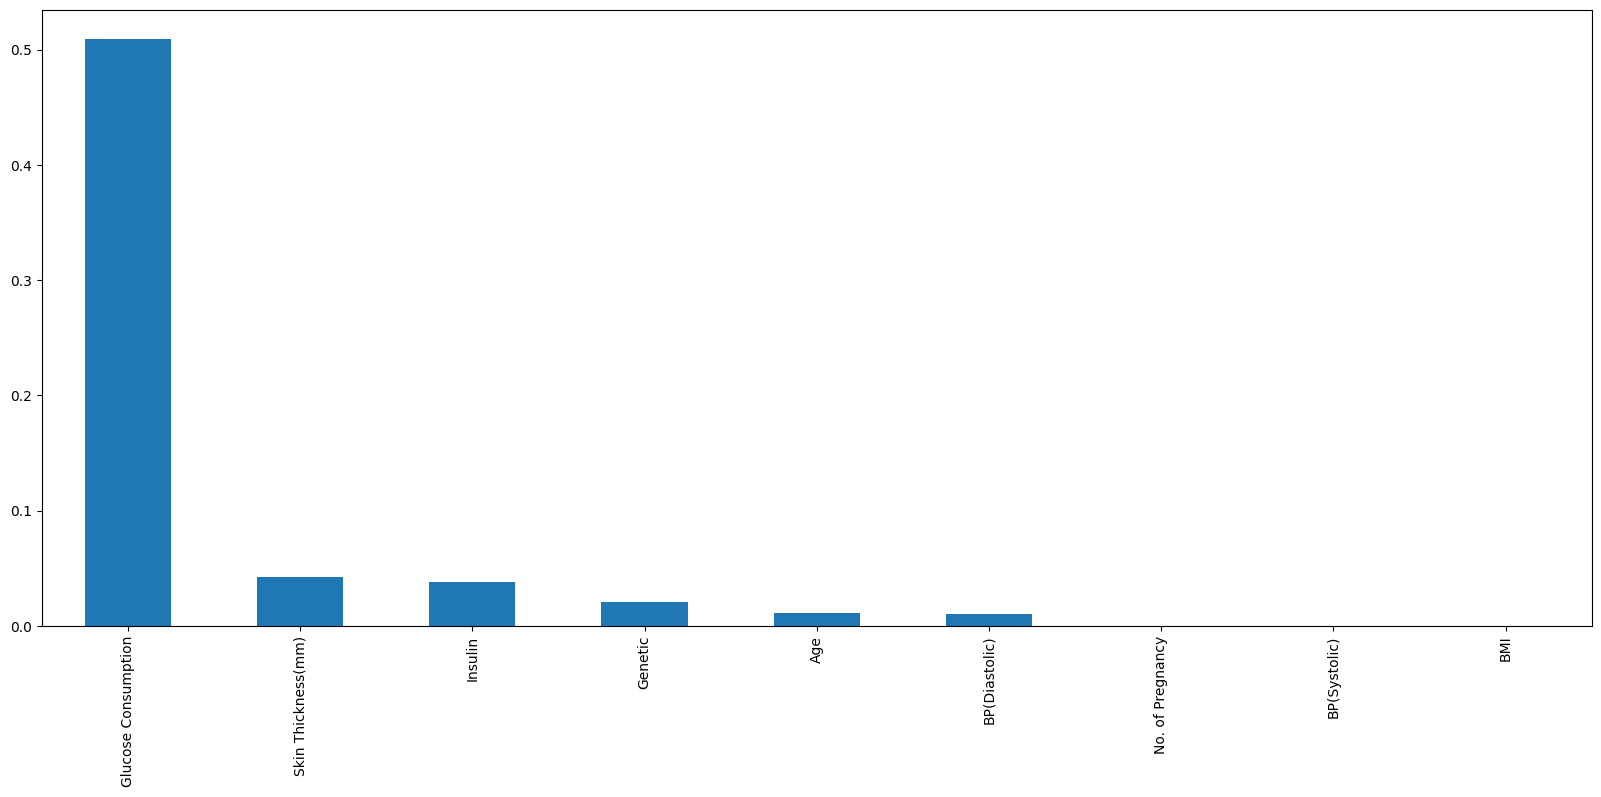

In [32]:
plt.figure(figsize = (20, 8))
mutual_info.sort_values(ascending = False).plot.bar();

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

lets smote

In [34]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [35]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Outcome
1    294
0     78
Name: count, dtype: int64

After SMOTE:
Outcome
1    294
0    294
Name: count, dtype: int64


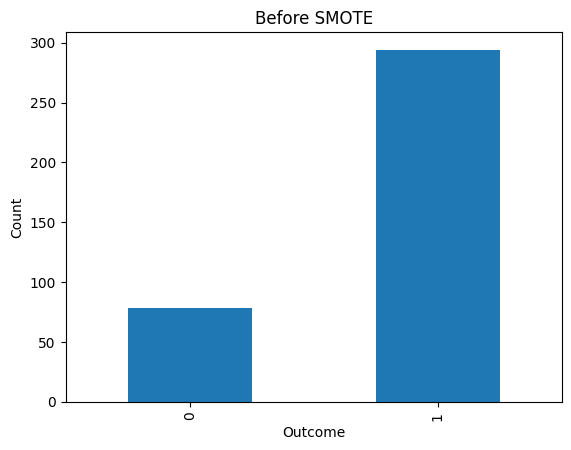

In [37]:
import matplotlib.pyplot as plt

y_train.value_counts().sort_index().plot(
    kind='bar',
    title='Before SMOTE'
)

plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

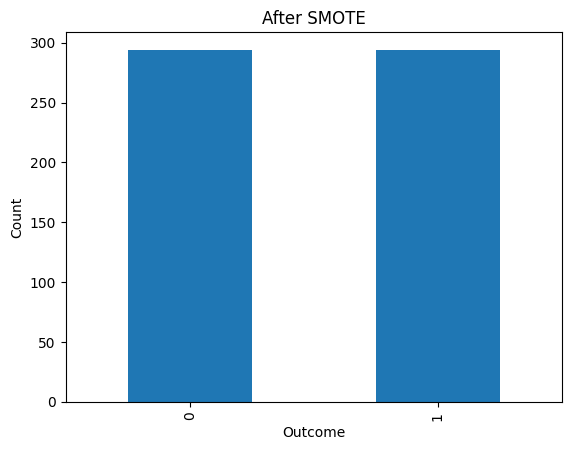

In [36]:
y_train_smote.value_counts().sort_index().plot(
    kind='bar',
    title='After SMOTE'
)

plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

Logistic regression

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(random_state=42)

lr.fit(X_train_smote, y_train_smote)

y_pred = lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9354838709677419
Precision: 1.0
Recall   : 0.9230769230769231
F1 Score : 0.96


In [39]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[15  0]
 [ 6 72]]


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    lr,                 # your trained LogisticRegression model
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring="f1"
)

print("F1 scores:", scores)
print("Mean F1:", scores.mean())

F1 scores: [0.92727273 0.93693694 0.97391304 0.91743119 0.96428571]
Mean F1: 0.9439679229268381


svm

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

svm = SVC(random_state=42)

svm.fit(X_train_smote, y_train_smote)

y_pred = svm.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9247311827956989
Precision: 0.9863013698630136
Recall   : 0.9230769230769231
F1 Score : 0.9536423841059603


KNN

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

knn = KNeighborsClassifier()

knn.fit(X_train_smote, y_train_smote)

y_pred = knn.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.8387096774193549
Precision: 0.9565217391304348
Recall   : 0.8461538461538461
F1 Score : 0.8979591836734694


Decision Tree

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

y_pred = dt.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


Random Forest

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

y_pred = rf.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [46]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train_smote, y_train_smote)

y_pred = gb.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_smote, y_train_smote)

y_pred = xgb.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
